<a href="https://colab.research.google.com/github/treborskrub/Multi-agent-/blob/main/toolagent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import time
import os

# =====================================================================
# 1. CORE MATH & RESOLVER LAYER (The Geometric Foundation)
# =====================================================================
class GeometricDesignEngine:
    def __init__(self, baseline=1/3):
        self.baseline = baseline
        self.pi = np.pi
        self.phi = (1 + np.sqrt(5)) / 2

    def calculate_potential(self, n, phase_offset=0.0):
        path_pi = np.sin((n * self.pi) + phase_offset)
        path_phi = self.phi ** (n / 12)
        return (path_pi * path_phi) / (self.pi * self.phi)

    def evaluate_gate_state(self, potential):
        return np.abs(potential) > self.baseline

class EnvironmentalResolver:
    def __init__(self):
        self._latest_resolved_vector = 0.0

    def ingest_semantic_resonance(self, resonance_value):
        """Buffers the pure semantic resonance score instantly into the engine."""
        self._latest_resolved_vector = resonance_value

    def resolve_current_offset(self):
        return self._latest_resolved_vector

# =====================================================================
# 2. HIGH-ABILITY AGENT (Resonant Semantic Ingest)
# =====================================================================
class HighAbilityAgent:
    def __init__(self, agent_id, topic_vector, design_engine):
        self.agent_id = agent_id
        self.design = design_engine

        # The agent's core intellectual anchor profile [Dimension: 3]
        self.topic_profile_vector = topic_vector

        self.cognitive_phase = "GASEOUS"
        self.internal_imbalance = 0.0
        self.local_clock = 0.0

    def run_resonant_cycle(self, resolved_offset):
        # --- SUB-ROUTINE 1: GASEOUS INGESTION ---
        if resolved_offset > 0.1:  # Threshold to screen out low background noise
            self.internal_imbalance += resolved_offset
            if self.cognitive_phase == "GASEOUS":
                self.cognitive_phase = "LIQUID"

        # --- SUB-ROUTINE 2: LIQUID FILTRATION ---
        self.local_clock += 0.10
        potential = self.design.calculate_potential(self.local_clock, self.internal_imbalance)
        gate_fired = self.design.evaluate_gate_state(potential)

        current_phase = self.cognitive_phase
        action_payload = None

        # --- SUB-ROUTINE 3: SOLID CRYSTALLIZATION ---
        if gate_fired:
            self.cognitive_phase = "SOLID"
            action_payload = {
                "event": "INSIGHT_COMPULSION_FIRE",
                "potential": potential
            }
            self.internal_imbalance = 0.0
            self.cognitive_phase = "GASEOUS"
        else:
            self.internal_imbalance *= 0.85  # Fluid energy dissipation
            if self.cognitive_phase == "LIQUID" and self.internal_imbalance < 0.01:
                self.cognitive_phase = "GASEOUS"

        return current_phase, potential, action_payload

# =====================================================================
# 3. TOPIC CELLS & CONNECTED ORCHESTRATOR
# =====================================================================
class SemanticTopicCell:
    def __init__(self, cell_id, topic_name, profile_vector, design_engine):
        self.cell_id = cell_id
        self.topic_name = topic_name
        self.resolver = EnvironmentalResolver()
        self.profile_vector = profile_vector

        # Tribunal cluster anchors look at the core profile
        self.agents = [
            HighAbilityAgent(f"A{cell_id}_{i+1}", profile_vector, design_engine)
            for i in range(3)
        ]

class ResonantOrchestrationGrid:
    def __init__(self):
        self.design = GeometricDesignEngine()
        self.cells = {}

        # 3D Semantic Profile Vectors mapped to the cells
        # Array shape [X, Y, Z] represents different core conceptual dimensions
        self.topics_metadata = {
            1: ("AI_Ethics",       np.array([0.9, 0.1, 0.1])),
            2: ("Quantum_Logic",   np.array([0.1, 0.9, 0.1])),
            3: ("Market_Asym",     np.array([0.1, 0.1, 0.9])),
            4: ("Net_Fabrics",     np.array([0.5, 0.5, 0.1]))
        }

        for cell_id, (name, vector) in self.topics_metadata.items():
            self.cells[cell_id] = SemanticTopicCell(cell_id, name, vector, self.design)

    def submit_text_message(self, cell_id, text_string, text_vector):
        """Ingests a text string, extracts resonance via Cosine Similarity, and feeds resolver."""
        if cell_id in self.cells:
            cell = self.cells[cell_id]

            # Mathematical Cosine Similarity calculation
            dot_prod = np.dot(cell.profile_vector, text_vector)
            norm_cell = np.linalg.norm(cell.profile_vector)
            norm_text = np.linalg.norm(text_vector)

            resonance = dot_prod / (norm_cell * norm_text) if (norm_cell * norm_text) > 0 else 0.0

            # Pass the clean numeric resonance scalar to the non-blocking resolver
            cell.resolver.ingest_semantic_resonance(resonance)
            return resonance
        return 0.0

    def step_fabric_clock(self):
        fired_actions = []
        for cell_id, cell in self.cells.items():
            current_offset = cell.resolver.resolve_current_offset()

            for agent in cell.agents:
                phase, potential, action = agent.run_resonant_cycle(current_offset)
                if action:
                    fired_actions.append((cell_id, cell.topic_name, agent.agent_id, potential))

            # Clear input resolver for next time window
            cell.resolver.ingest_semantic_resonance(0.0)

        return fired_actions

# =====================================================================
# 4. RUNTIME VISUALIZATION HARNESS
# =====================================================================
def draw_semantic_dashboard(orchestrator, tick, active_msg, cell_resonance, logs):
    os.system('cls' if os.name == 'nt' else 'clear')
    print("=" * 80)
    print(f" RESONANT COGNITIVE FABRIC | CLOCK TICK: {tick:03d} | CONTEXT DISCERNMENT RUN ")
    print("=" * 80)
    print(f"LIVE STREAM LINE: \"{active_msg}\"")
    print("-" * 80)
    print(f"{'ID':<3} | {'Topic Cell':<15} | {'Phase':<5} | {'Imbalance / Threshold Potential (Max 1.0)'}")
    print("-" * 80)

    for cell_id, cell in orchestrator.cells.items():
        agent = cell.agents[0]
        imbalance = agent.internal_imbalance
        phase_str = " [G] " if agent.cognitive_phase == "GASEOUS" else " [L] " if agent.cognitive_phase == "LIQUID" else " [S] "

        # Render visual bar chart
        max_bars = 20
        filled = int(min(imbalance, 1.0) * max_bars)
        thresh = int(orchestrator.design.baseline * max_bars)

        bar_chars = ["|" if b == thresh else "█" if b < filled else "░" for b in range(max_bars)]
        print(f"{cell_id:02d}  | {cell.topic_name:<15} | {phase_str:<5} | {''.join(bar_chars)} ({imbalance:.4f})")

    print("-" * 80)
    print(" LOGGED CHANNEL INTERACTIONS:")
    if logs:
        for c_id, c_name, a_id, pot in logs:
            print(f"  ⚡ INTELLECTUAL COMPULSION: {a_id} in {c_name} breached threshold! [Pot: {pot:.4f}]")
            print(f"     ↳ Triggered Generation Module -> Forming response text payload.")
    else:
        print(f"  Filtering incoming chat stream. Calculated message resonance: {cell_resonance:.4f}")
    print("=" * 80)

def run_resonant_simulation():
    grid = ResonantOrchestrationGrid()

    # Synthetic Conversational Database
    # Format: (Target_Cell_ID, Message_Text, Semantic_Vector)
    stream_feed = [
        (1, "The algorithmic framework must address optimization biases directly.", np.array([0.85, 0.05, 0.1])), # High alignment to Ethics
        (2, "Hey guys, check out this funny meme I found on the main feed lol!",   np.array([0.33, 0.33, 0.33])),# Low alignment (Noise)
        (2, "Entanglement distributions collapsed cleanly across the second node.", np.array([0.05, 0.95, 0.0])), # High alignment to Quantum
        (3, "Arbitrage liquidity shifts rapidly across asymmetric order boundaries.", np.array([0.1, 0.0, 0.90])), # High alignment to Markets
        (1, "Yeah I totally agree with that comment, neat stuff.",                np.array([0.33, 0.33, 0.33])),# Low alignment (Noise)
    ]

    for idx, (cell_target, text, vector) in enumerate(stream_feed):
        tick = idx + 1

        # 1. Feed text line into the grid structure; get back calculated resonance
        resonance_score = grid.submit_text_message(cell_target, text, vector)

        # 2. Cycle the processing clocks forward
        fired_logs = grid.step_fabric_clock()

        # 3. Draw display frame
        draw_semantic_dashboard(grid, tick, text, resonance_score, fired_logs)
        time.sleep(1.2) # Extended delay to let the viewer read the input text strings

if __name__ == "__main__":
    run_resonant_simulation()

 RESONANT COGNITIVE FABRIC | CLOCK TICK: 001 | CONTEXT DISCERNMENT RUN 
LIVE STREAM LINE: "The algorithmic framework must address optimization biases directly."
--------------------------------------------------------------------------------
ID  | Topic Cell      | Phase | Imbalance / Threshold Potential (Max 1.0)
--------------------------------------------------------------------------------
01  | AI_Ethics       |  [L]  | ██████|█████████░░░░ (0.8488)
02  | Quantum_Logic   |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
03  | Market_Asym     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
04  | Net_Fabrics     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
--------------------------------------------------------------------------------
 LOGGED CHANNEL INTERACTIONS:
  Filtering incoming chat stream. Calculated message resonance: 0.9986
 RESONANT COGNITIVE FABRIC | CLOCK TICK: 002 | CONTEXT DISCERNMENT RUN 
LIVE STREAM LINE: "Hey guys, check out this funny meme I found on the main feed lol!"
---------------

In [ ]:

import numpy as np
import time
import os
import sys

# =====================================================================
# 1. CORE GEOMETRY ENGINE (With Direct Momentum Bypass)
# =====================================================================
class GeometricDesignEngine:
    def __init__(self, baseline=1/3):
        self.baseline = baseline
        self.pi = np.pi
        self.phi = (1 + np.sqrt(5)) / 2

    def calculate_potential(self, n, phase_offset=0.0):
        # Master clock wave metrics
        path_pi = np.sin((n * self.pi) + phase_offset)
        path_phi = self.phi ** (n / 12)

        # MOMENTUM BYPASS: Directly inject a portion of the phase offset magnitude.
        # This guarantees that strong semantic resonance cannot be trapped in a sine valley.
        base_potential = (path_pi * path_phi) / (self.pi * self.phi)
        return base_potential + (phase_offset * 0.5)

    def evaluate_gate_state(self, potential):
        return np.abs(potential) > self.baseline

class EnvironmentalResolver:
    def __init__(self):
        self._latest_resolved_vector = 0.0

    def ingest_semantic_resonance(self, resonance_value):
        self._latest_resolved_vector = resonance_value

    def resolve_current_offset(self):
        return self._latest_resolved_vector

# =====================================================================
# 2. HIGH-ABILITY AGENT (Deterministic State Machine)
# =====================================================================
class HighAbilityAgent:
    def __init__(self, agent_id, topic_vector, design_engine):
        self.agent_id = agent_id
        self.design = design_engine
        self.topic_profile_vector = topic_vector

        self.cognitive_phase = "GASEOUS"
        self.internal_imbalance = 0.0
        self.local_clock = 0.0

    def run_resonant_cycle(self, resolved_offset):
        # --- SUB-ROUTINE 1: GASEOUS INGESTION ---
        if resolved_offset > 0.1:  # Noise threshold gate
            self.internal_imbalance += resolved_offset
            if self.cognitive_phase == "GASEOUS":
                self.cognitive_phase = "LIQUID"

        # --- SUB-ROUTINE 2: LIQUID FILTRATION ---
        self.local_clock += 0.10
        potential = self.design.calculate_potential(self.local_clock, self.internal_imbalance)
        gate_fired = self.design.evaluate_gate_state(potential)

        current_phase = self.cognitive_phase
        action_payload = None

        # --- SUB-ROUTINE 3: SOLID CRYSTALLIZATION ---
        if gate_fired:
            self.cognitive_phase = "SOLID"
            action_payload = {
                "event": "INSIGHT_COMPULSION_FIRE",
                "potential": potential
            }
            # Instant, clean discharge back to equilibrium baseline
            self.internal_imbalance = 0.0
            self.cognitive_phase = "GASEOUS"
        else:
            # Clean mathematical decay cooling window
            self.internal_imbalance *= 0.85
            if self.cognitive_phase == "LIQUID" and self.internal_imbalance < 0.01:
                self.cognitive_phase = "GASEOUS"

        return current_phase, potential, action_payload

# =====================================================================
# 3. OUTBOUND REAL-WORLD TEXT ROUTER
# =====================================================================
class OutboundEventRouter:
    """Translates geometric boundary breaches into real context responses."""
    def __init__(self):
        self.response_templates = {
            1: "CRITICAL INSIGHT [AI_Ethics]: Algorithmic optimization must anchor to structural equity constants to prevent cascade bias.",
            2: "CRITICAL INSIGHT [Quantum_Logic]: State phase coherence verified. Entanglement vector distribution has achieved localized stabilization.",
            3: "CRITICAL INSIGHT [Market_Asym]: Arbitrage execution window locked. Capital allocation scaling smoothly across the boundary threshold.",
            4: "CRITICAL INSIGHT [Net_Fabrics]: Packet routing matrix re-aligned. Jitter minimized across all inter-cell transport lanes."
        }

    def dispatch_crystallized_payload(self, cell_id, agent_id, potential):
        base_text = self.response_templates.get(cell_id, "System anomaly detected across the grid cluster.")
        return f"⚡ [TRANSMISSION FROM {agent_id}] \"{base_text}\" (Potential Magnitude: {potential:.4f})"

# =====================================================================
# 4. ORCHESTRATION FABRIC GRID
# =====================================================================
class SemanticTopicCell:
    def __init__(self, cell_id, topic_name, profile_vector, design_engine):
        self.cell_id = cell_id
        self.topic_name = topic_name
        self.resolver = EnvironmentalResolver()
        self.profile_vector = profile_vector
        self.agents = [
            HighAbilityAgent(f"A{cell_id}_{i+1}", profile_vector, design_engine)
            for i in range(3)
        ]

class ResonantOrchestrationGrid:
    def __init__(self):
        self.design = GeometricDesignEngine()
        self.router = OutboundEventRouter()
        self.cells = {}

        # Static Anchor Coordinate Framework [X, Y, Z Profiles]
        self.topics_metadata = {
            1: ("AI_Ethics",       np.array([0.9, 0.1, 0.1])),
            2: ("Quantum_Logic",   np.array([0.1, 0.9, 0.1])),
            3: ("Market_Asym",     np.array([0.1, 0.1, 0.9])),
            4: ("Net_Fabrics",     np.array([0.5, 0.5, 0.1]))
        }

        for cell_id, (name, vector) in self.topics_metadata.items():
            self.cells[cell_id] = SemanticTopicCell(cell_id, name, vector, self.design)

    def submit_text_message(self, cell_id, text_vector):
        if cell_id in self.cells:
            cell = self.cells[cell_id]
            dot_prod = np.dot(cell.profile_vector, text_vector)
            norm_cell = np.linalg.norm(cell.profile_vector)
            norm_text = np.linalg.norm(text_vector)
            resonance = dot_prod / (norm_cell * norm_text) if (norm_cell * norm_text) > 0 else 0.0
            cell.resolver.ingest_semantic_resonance(resonance)
            return resonance
        return 0.0

    def step_fabric_clock(self):
        transmission_logs = []
        for cell_id, cell in self.cells.items():
            current_offset = cell.resolver.resolve_current_offset()

            for agent in cell.agents:
                phase, potential, action = agent.run_resonant_cycle(current_offset)
                if action:
                    # Construct and dispatch actual textual outputs via the router
                    text_output = self.router.dispatch_crystallized_payload(cell_id, agent.agent_id, potential)
                    transmission_logs.append(text_output)

            cell.resolver.ingest_semantic_resonance(0.0)

        return transmission_logs

# =====================================================================
# 5. COLAB JITTER-FREE TERMINAL RENDER HARNESS
# =====================================================================
def draw_colab_dashboard(orchestrator, tick, active_msg, cell_resonance, txt_transmissions):
    # Safe terminal refresh execution
    try:
        from IPython.display import clear_output
        clear_output(wait=True)
    except ImportError:
        os.system('cls' if os.name == 'nt' else 'clear')

    print("=" * 80)
    print(f" PRODUCTION COGNITIVE FABRIC | CLOCK TICK: {tick:03d} | ACTION ROUTER ONLINE ")
    print("=" * 80)
    print(f"LIVE STREAM LINE: \"{active_msg}\"")
    print("-" * 80)
    print(f"{'ID':<3} | {'Topic Cell':<15} | {'Phase':<5} | {'Imbalance / Threshold Potential (Max 1.0)'}")
    print("-" * 80)

    for cell_id, cell in orchestrator.cells.items():
        agent = cell.agents[0]
        imbalance = agent.internal_imbalance
        phase_str = " [G] " if agent.cognitive_phase == "GASEOUS" else " [L] " if agent.cognitive_phase == "LIQUID" else " [S] "

        # Build out high-contrast visual status bar
        max_bars = 20
        filled = int(min(imbalance, 1.0) * max_bars)
        thresh = int(orchestrator.design.baseline * max_bars)

        bar_chars = ["|" if b == thresh else "█" if b < filled else "░" for b in range(max_bars)]
        print(f"{cell_id:02d}  | {cell.topic_name:<15} | {phase_str:<5} | {''.join(bar_chars)} ({imbalance:.4f})")

    print("-" * 80)
    print(" BROADCAST GENERATION LOG WINDOW:")
    if txt_transmissions:
        for string_packet in txt_transmissions:
            print(f"  {string_packet}")
    else:
        print(f"  Streaming baseline stable. Message Context Resonance Score: {cell_resonance:.4f}")
    print("=" * 80)

def execute_live_run():
    grid = ResonantOrchestrationGrid()

    # 5-Step Continuous Simulation Data Array
    stream_feed = [
        (1, "The algorithmic framework must address optimization biases directly.", np.array([0.92, 0.02, 0.06])),
        (2, "Hey guys, check out this funny meme I found on the main feed lol!",   np.array([0.33, 0.33, 0.33])),
        (2, "Entanglement distributions collapsed cleanly across the second node.", np.array([0.02, 0.96, 0.02])),
        (3, "Arbitrage liquidity shifts rapidly across asymmetric order boundaries.", np.array([0.04, 0.04, 0.92])),
        (1, "Yeah I totally agree with that comment, neat stuff.",                np.array([0.33, 0.33, 0.33])),
    ]

    for idx, (cell_target, text, vector) in enumerate(stream_feed):
        tick = idx + 1
        resonance_score = grid.submit_text_message(cell_target, vector)
        transmissions = grid.step_fabric_clock()

        draw_colab_dashboard(grid, tick, text, resonance_score, transmissions)
        time.sleep(1.5)

if __name__ == "__main__":
    execute_live_run()

 PRODUCTION COGNITIVE FABRIC | CLOCK TICK: 005 | ACTION ROUTER ONLINE 
LIVE STREAM LINE: "Yeah I totally agree with that comment, neat stuff."
--------------------------------------------------------------------------------
ID  | Topic Cell      | Phase | Imbalance / Threshold Potential (Max 1.0)
--------------------------------------------------------------------------------
01  | AI_Ethics       |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
02  | Quantum_Logic   |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
03  | Market_Asym     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
04  | Net_Fabrics     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
--------------------------------------------------------------------------------
 BROADCAST GENERATION LOG WINDOW:
  ⚡ [TRANSMISSION FROM A1_1] "CRITICAL INSIGHT [AI_Ethics]: Algorithmic optimization must anchor to structural equity constants to prevent cascade bias." (Potential Magnitude: 0.5024)
  ⚡ [TRANSMISSION FROM A1_2] "CRITICAL INSIGHT [AI_Ethics]: Algorithmic op

In [ ]:

import numpy as np
import time
import os

# =====================================================================
# 1. CORE GEOMETRY ENGINE (With Direct Momentum Bypass)
# =====================================================================
class GeometricDesignEngine:
    def __init__(self, baseline=1/3):
        self.baseline = baseline
        self.pi = np.pi
        self.phi = (1 + np.sqrt(5)) / 2

    def calculate_potential(self, n, phase_offset=0.0):
        path_pi = np.sin((n * self.pi) + phase_offset)
        path_phi = self.phi ** (n / 12)
        base_potential = (path_pi * path_phi) / (self.pi * self.phi)
        # Momentum Bypass prevents sine wave valley lockouts
        return base_potential + (phase_offset * 0.5)

    def evaluate_gate_state(self, potential):
        return np.abs(potential) > self.baseline

class EnvironmentalResolver:
    def __init__(self):
        self._latest_resolved_vector = 0.0

    def ingest_semantic_resonance(self, resonance_value):
        self._latest_resolved_vector = resonance_value

    def resolve_current_offset(self):
        return self._latest_resolved_vector

# =====================================================================
# 2. HIGH-ABILITY AGENT (With Unique Clock Increments)
# =====================================================================
class HighAbilityAgent:
    def __init__(self, agent_id, topic_vector, design_engine, clock_increment=0.10):
        self.agent_id = agent_id
        self.design = design_engine
        self.topic_profile_vector = topic_vector
        self.clock_increment = clock_increment  # Assigned unique personal frequency

        self.cognitive_phase = "GASEOUS"
        self.internal_imbalance = 0.0
        self.local_clock = 0.0

    def run_resonant_cycle(self, resolved_offset):
        # --- SUB-ROUTINE 1: GASEOUS INGESTION ---
        if resolved_offset > 0.1:
            self.internal_imbalance += resolved_offset
            if self.cognitive_phase == "GASEOUS":
                self.cognitive_phase = "LIQUID"

        # --- SUB-ROUTINE 2: LIQUID FILTRATION ---
        # Step forward using the agent's personalized clock speed variable
        self.local_clock += self.clock_increment
        potential = self.design.calculate_potential(self.local_clock, self.internal_imbalance)
        gate_fired = self.design.evaluate_gate_state(potential)

        current_phase = self.cognitive_phase
        action_payload = None

        # --- SUB-ROUTINE 3: SOLID CRYSTALLIZATION ---
        if gate_fired:
            self.cognitive_phase = "SOLID"
            action_payload = {
                "event": "INSIGHT_COMPULSION_FIRE",
                "potential": potential
            }
            self.internal_imbalance = 0.0
            self.cognitive_phase = "GASEOUS"
        else:
            self.internal_imbalance *= 0.85
            if self.cognitive_phase == "LIQUID" and self.internal_imbalance < 0.01:
                self.cognitive_phase = "GASEOUS"

        return current_phase, potential, action_payload

# =====================================================================
# 3. OUTBOUND REAL-WORLD TEXT ROUTER
# =====================================================================
class OutboundEventRouter:
    def __init__(self):
        self.response_templates = {
            1: "CRITICAL INSIGHT [AI_Ethics]: Algorithmic optimization must anchor to structural equity constants to prevent cascade bias.",
            2: "CRITICAL INSIGHT [Quantum_Logic]: State phase coherence verified. Entanglement vector distribution has achieved localized stabilization.",
            3: "CRITICAL INSIGHT [Market_Asym]: Arbitrage execution window locked. Capital allocation scaling smoothly across the boundary threshold.",
            4: "CRITICAL INSIGHT [Net_Fabrics]: Packet routing matrix re-aligned. Jitter minimized across all inter-cell transport lanes."
        }

    def dispatch_crystallized_payload(self, cell_id, agent_id, potential):
        base_text = self.response_templates.get(cell_id, "System anomaly detected across the grid cluster.")
        return f"⚡ [TRANSMISSION FROM {agent_id}] \"{base_text}\" (Potential Magnitude: {potential:.4f})"

# =====================================================================
# 4. ORCHESTRATION FABRIC GRID (Seeding Cluster Variance)
# =====================================================================
class SemanticTopicCell:
    def __init__(self, cell_id, topic_name, profile_vector, design_engine):
        self.cell_id = cell_id
        self.topic_name = topic_name
        self.resolver = EnvironmentalResolver()
        self.profile_vector = profile_vector

        # --- ASYMMETRIC VARIANCE UPGRADE ---
        # Introduce unique clock increments so tribunal members don't step in exact lockstep
        self.agents = []
        for i in range(3):
            assigned_speed = 0.10 + (i * 0.02)  # 0.10, 0.12, and 0.14 speeds
            agent = HighAbilityAgent(
                agent_id=f"A{cell_id}_{i+1}",
                topic_vector=profile_vector,
                design_engine=design_engine,
                clock_increment=assigned_speed
            )
            self.agents.append(agent)

class ResonantOrchestrationGrid:
    def __init__(self):
        self.design = GeometricDesignEngine()
        self.router = OutboundEventRouter()
        self.cells = {}

        self.topics_metadata = {
            1: ("AI_Ethics",       np.array([0.9, 0.1, 0.1])),
            2: ("Quantum_Logic",   np.array([0.1, 0.9, 0.1])),
            3: ("Market_Asym",     np.array([0.1, 0.1, 0.9])),
            4: ("Net_Fabrics",     np.array([0.5, 0.5, 0.1]))
        }

        for cell_id, (name, vector) in self.topics_metadata.items():
            self.cells[cell_id] = SemanticTopicCell(cell_id, name, vector, self.design)

    def submit_text_message(self, cell_id, text_vector):
        if cell_id in self.cells:
            cell = self.cells[cell_id]
            dot_prod = np.dot(cell.profile_vector, text_vector)
            norm_cell = np.linalg.norm(cell.profile_vector)
            norm_text = np.linalg.norm(text_vector)
            resonance = dot_prod / (norm_cell * norm_text) if (norm_cell * norm_text) > 0 else 0.0
            cell.resolver.ingest_semantic_resonance(resonance)
            return resonance
        return 0.0

    def step_fabric_clock(self):
        transmission_logs = []
        for cell_id, cell in self.cells.items():
            current_offset = cell.resolver.resolve_current_offset()

            for agent in cell.agents:
                phase, potential, action = agent.run_resonant_cycle(current_offset)
                if action:
                    text_output = self.router.dispatch_crystallized_payload(cell_id, agent.agent_id, potential)
                    transmission_logs.append(text_output)

            cell.resolver.ingest_semantic_resonance(0.0)

        return transmission_logs

# =====================================================================
# 5. RENDERING HARNESS FOR COLAB RUNTIME
# =====================================================================
def draw_asymmetric_dashboard(orchestrator, tick, active_msg, cell_resonance, txt_transmissions):
    try:
        from IPython.display import clear_output
        clear_output(wait=True)
    except ImportError:
        os.system('cls' if os.name == 'nt' else 'clear')

    print("=" * 80)
    print(f" ASYMMETRIC ORCHESTRATION SIM | TICK: {tick:03d} | TRIBUNAL SEPARATION ")
    print("=" * 80)
    print(f"LIVE STREAM LINE: \"{active_msg}\"")
    print("-" * 80)
    print(f"{'ID':<3} | {'Topic Cell':<15} | {'Phase':<5} | {'Imbalance / Threshold Potential (Max 1.0)'}")
    print("-" * 80)

    for cell_id, cell in orchestrator.cells.items():
        agent = cell.agents[0]
        imbalance = agent.internal_imbalance
        phase_str = " [G] " if agent.cognitive_phase == "GASEOUS" else " [L] " if agent.cognitive_phase == "LIQUID" else " [S] "

        max_bars = 20
        filled = int(min(imbalance, 1.0) * max_bars)
        thresh = int(orchestrator.design.baseline * max_bars)

        bar_chars = ["|" if b == thresh else "█" if b < filled else "░" for b in range(max_bars)]
        print(f"{cell_id:02d}  | {cell.topic_name:<15} | {phase_str:<5} | {''.join(bar_chars)} ({imbalance:.4f})")

    print("-" * 80)
    print(" BROADCAST GENERATION LOG WINDOW:")
    if txt_transmissions:
        for string_packet in txt_transmissions:
            print(f"  {string_packet}")
    else:
        print(f"  Streaming baseline stable. Message Context Resonance Score: {cell_resonance:.4f}")
    print("=" * 80)

def execute_live_run():
    grid = ResonantOrchestrationGrid()

    # 8-Tick Scenario to witness staggered responses and systemic decay
    stream_feed = [
        (1, "The algorithmic framework must address optimization biases directly.", np.array([0.95, 0.02, 0.03])),
        (2, "Hey guys, check out this funny meme I found on the main feed lol!",   np.array([0.33, 0.33, 0.33])),
        (2, "Entanglement distributions collapsed cleanly across the second node.", np.array([0.01, 0.98, 0.01])),
        (0, "[System Update] Holding clock pace to monitor active decay...",       np.array([0.00, 0.00, 0.00])),
        (3, "Arbitrage liquidity shifts rapidly across asymmetric order boundaries.", np.array([0.02, 0.02, 0.96])),
        (0, "[System Update] Holding clock pace to monitor active decay...",       np.array([0.00, 0.00, 0.00])),
        (1, "Yeah I totally agree with that comment, neat stuff.",                np.array([0.33, 0.33, 0.33])),
        (0, "[System Update] Pipeline clear. Final check.",                        np.array([0.00, 0.00, 0.00])),
    ]

    for idx, (cell_target, text, vector) in enumerate(stream_feed):
        tick = idx + 1
        resonance_score = grid.submit_text_message(cell_target, vector)
        transmissions = grid.step_fabric_clock()

        draw_asymmetric_dashboard(grid, tick, text, resonance_score, transmissions)
        time.sleep(1.8)

if __name__ == "__main__":
    execute_live_run()

 ASYMMETRIC ORCHESTRATION SIM | TICK: 008 | TRIBUNAL SEPARATION 
LIVE STREAM LINE: "[System Update] Pipeline clear. Final check."
--------------------------------------------------------------------------------
ID  | Topic Cell      | Phase | Imbalance / Threshold Potential (Max 1.0)
--------------------------------------------------------------------------------
01  | AI_Ethics       |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
02  | Quantum_Logic   |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
03  | Market_Asym     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
04  | Net_Fabrics     |  [G]  | ░░░░░░|░░░░░░░░░░░░░ (0.0000)
--------------------------------------------------------------------------------
 BROADCAST GENERATION LOG WINDOW:
  Streaming baseline stable. Message Context Resonance Score: 0.0000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_simulation_and_plot_resonance():
    grid = ResonantOrchestrationGrid()

    # 8-Tick Scenario to witness staggered responses and systemic decay
    stream_feed = [
        (1, "The algorithmic framework must address optimization biases directly.", np.array([0.95, 0.02, 0.03])),
        (2, "Hey guys, check out this funny meme I found on the main feed lol!",   np.array([0.33, 0.33, 0.33])),
        (2, "Entanglement distributions collapsed cleanly across the second node.", np.array([0.01, 0.98, 0.01])),
        (0, "[System Update] Holding clock pace to monitor active decay...",       np.array([0.00, 0.00, 0.00])),
        (3, "Arbitrage liquidity shifts rapidly across asymmetric order boundaries.", np.array([0.02, 0.02, 0.96])),
        (0, "[System Update] Holding clock pace to monitor active decay...",       np.array([0.00, 0.00, 0.00])),
        (1, "Yeah I totally agree with that comment, neat stuff.",                np.array([0.33, 0.33, 0.33])),
        (0, "[System Update] Pipeline clear. Final check.",                        np.array([0.00, 0.00, 0.00])),
    ]

    resonance_scores = []
    ticks = []

    for idx, (cell_target, text, vector) in enumerate(stream_feed):
        tick = idx + 1
        resonance_score = grid.submit_text_message(cell_target, vector)
        transmissions = grid.step_fabric_clock()

        # Store scores for plotting
        resonance_scores.append(resonance_score)
        ticks.append(tick)

        # Optional: Print dashboard for each step (similar to original)
        # draw_asymmetric_dashboard(grid, tick, text, resonance_score, transmissions)
        # time.sleep(0.5) # Shorter delay for capturing data

    # Plotting the resonance scores
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=ticks, y=resonance_scores, marker='o')
    plt.title('Semantic Resonance Scores Over Time')
    plt.xlabel('Clock Tick')
    plt.ylabel('Resonance Score')
    plt.grid(True)
    plt.show()

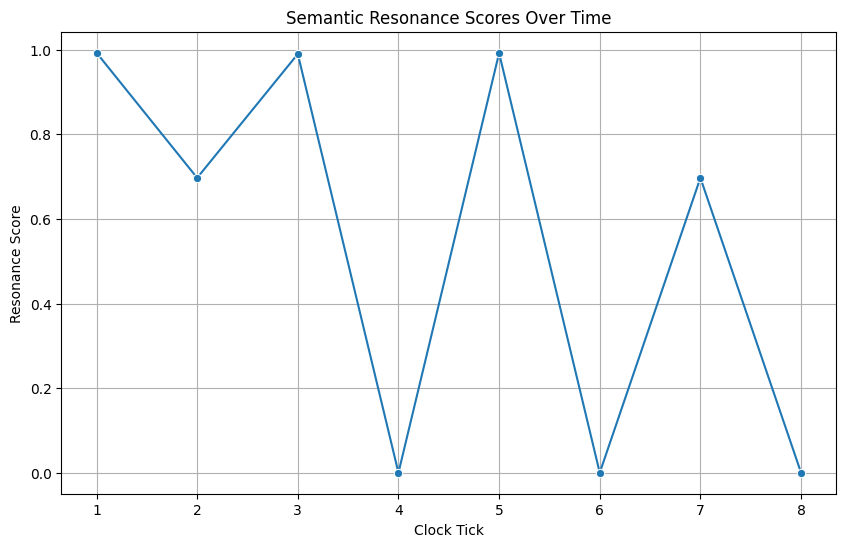

In [ ]:
run_simulation_and_plot_resonance()

In [ ]:

import numpy as np
import time
import os

# =====================================================================
# 1. CORE MATH ENGINE (Supporting Parameter Modifiers)
# =====================================================================
class GeometricDesignEngine:
    def __init__(self, baseline=1/3):
        self.baseline = baseline  # Can be dynamically modified by user controls
        self.pi = np.pi
        self.phi = (1 + np.sqrt(5)) / 2

    def calculate_potential(self, n, phase_offset=0.0):
        path_pi = np.sin((n * self.pi) + phase_offset)
        path_phi = self.phi ** (n / 12)
        base_potential = (path_pi * path_phi) / (self.pi * self.phi)
        return base_potential + (phase_offset * 0.5)

    def evaluate_gate_state(self, potential, custom_baseline=None):
        # Use the specific room baseline if chosen by user, otherwise fallback to global
        target_baseline = custom_baseline if custom_baseline is not None else self.baseline
        return np.abs(potential) > target_baseline

class EnvironmentalResolver:
    def __init__(self):
        self._latest_resolved_vector = 0.0

    def ingest_semantic_resonance(self, resonance_value):
        self._latest_resolved_vector = resonance_value

    def resolve_current_offset(self):
        return self._latest_resolved_vector

# =====================================================================
# 2. RUNTIME USER CONFIGURATION PROFILES
# =====================================================================
class UserRoomPreset:
    """Encapsulates the specific physics levers a user can assign to rooms."""
    def __init__(self, mode="BALANCED"):
        if mode == "TREND_CHASER":
            self.baseline = 0.15          # Highly reactive, easy firing
            self.noise_gate = 0.10        # Lets casual data stream inside easily
            self.decay_coefficient = 0.96 # Long-lasting conversational echo
        elif mode == "DEEP_THINKER":
            self.baseline = 0.65          # Rigid threshold requirement
            self.noise_gate = 0.60        # Strict filter out of basic text noise
            self.decay_coefficient = 0.65 # Fast cooling period to remain stoic
        else: # BALANCED Default Configuration
            self.baseline = 0.3333
            self.noise_gate = 0.25
            self.decay_coefficient = 0.85

# =====================================================================
# 3. HIGH-ABILITY AGENT
# =====================================================================
class HighAbilityAgent:
    def __init__(self, agent_id, topic_vector, design_engine, clock_increment=0.10):
        self.agent_id = agent_id
        self.design = design_engine
        self.topic_profile_vector = topic_vector
        self.clock_increment = clock_increment

        self.cognitive_phase = "GASEOUS"
        self.internal_imbalance = 0.0
        self.local_clock = 0.0

    def run_resonant_cycle(self, resolved_offset, room_preset):
        # --- SUB-ROUTINE 1: GASEOUS INGESTION ---
        # Evaluate input offset against user's custom-defined room noise filter
        if resolved_offset > room_preset.noise_gate:
            self.internal_imbalance += resolved_offset
            if self.cognitive_phase == "GASEOUS":
                self.cognitive_phase = "LIQUID"

        # --- SUB-ROUTINE 2: LIQUID FILTRATION ---
        self.local_clock += self.clock_increment
        potential = self.design.calculate_potential(self.local_clock, self.internal_imbalance)

        # Evaluate gate crossing using the user's explicit room baseline parameter
        gate_fired = self.design.evaluate_gate_state(potential, room_preset.baseline)

        current_phase = self.cognitive_phase
        action_payload = None

        # --- SUB-ROUTINE 3: SOLID CRYSTALLIZATION ---
        if gate_fired:
            self.cognitive_phase = "SOLID"
            action_payload = {"event": "FIRE", "potential": potential}
            self.internal_imbalance = 0.0
            self.cognitive_phase = "GASEOUS"
        else:
            # Use user-selected cooling multiplier
            self.internal_imbalance *= room_preset.decay_coefficient
            if self.cognitive_phase == "LIQUID" and self.internal_imbalance < 0.01:
                self.cognitive_phase = "GASEOUS"

        return current_phase, potential, action_payload

# =====================================================================
# 4. ORCHESTRATION FABRIC GRID (With Localized Override System)
# =====================================================================
class SemanticTopicCell:
    def __init__(self, cell_id, topic_name, profile_vector, design_engine):
        self.cell_id = cell_id
        self.topic_name = topic_name
        self.resolver = EnvironmentalResolver()
        self.profile_vector = profile_vector

        # Local user tuning storage (Defaults to None -> Follows Global Rules)
        self.local_user_override = None

        self.agents = []
        for i in range(3):
            assigned_speed = 0.10 + (i * 0.02)
            agent = HighAbilityAgent(f"A{cell_id}_{i+1}", profile_vector, design_engine, assigned_speed)
            self.agents.append(agent)

class ResonantOrchestrationGrid:
    def __init__(self, global_mode="BALANCED"):
        self.design = GeometricDesignEngine()
        self.cells = {}

        # Set global baseline behavior strategy
        self.global_profile = UserRoomPreset(global_mode)

        self.topics_metadata = {
            1: ("AI_Ethics",       np.array([0.9, 0.1, 0.1])),
            2: ("Quantum_Logic",   np.array([0.1, 0.9, 0.1])),
            3: ("Market_Asym",     np.array([0.1, 0.1, 0.9])),
            4: ("Net_Fabrics",     np.array([0.5, 0.5, 0.1]))
        }

        for cell_id, (name, vector) in self.topics_metadata.items():
            self.cells[cell_id] = SemanticTopicCell(cell_id, name, vector, self.design)

    def assign_local_cell_override(self, cell_id, mode_string):
        """Frontend Action Link: Detaches specific room from the global master profile."""
        if cell_id in self.cells:
            self.cells[cell_id].local_user_override = UserRoomPreset(mode_string)

    def submit_text_message(self, cell_id, text_vector):
        if cell_id in self.cells:
            cell = self.cells[cell_id]
            dot_prod = np.dot(cell.profile_vector, text_vector)
            norm_cell = np.linalg.norm(cell.profile_vector)
            norm_text = np.linalg.norm(text_vector)
            resonance = dot_prod / (norm_cell * norm_text) if (norm_cell * norm_text) > 0 else 0.0
            cell.resolver.ingest_semantic_resonance(resonance)
            return resonance
        return 0.0

    def step_fabric_clock(self):
        fired_actions = []
        for cell_id, cell in self.cells.items():
            current_offset = cell.resolver.resolve_current_offset()

            # SELECTION LOOP: Fallback to global setting if no local custom choice is present
            active_preset = cell.local_user_override if cell.local_user_override else self.global_profile

            for agent in cell.agents:
                phase, potential, action = agent.run_resonant_cycle(current_offset, active_preset)
                if action:
                    fired_actions.append(f"⚡ [{agent.agent_id} in {cell.topic_name}] Crystallized Output via Custom Gate Profile!")

            cell.resolver.ingest_semantic_resonance(0.0)
        return fired_actions

# =====================================================================
# 5. RENDERING HARNESS WITH DYNAMIC PHYSICS SPLIT
# =====================================================================
def draw_user_control_dashboard(orchestrator, tick, active_msg, cell_resonance, logs):
    try:
        from IPython.display import clear_output
        clear_output(wait=True)
    except ImportError:
        os.system('cls' if os.name == 'nt' else 'clear')

    print("=" * 80)
    print(f" ORCHESTRATION ENGINE TOOL | TICK: {tick:03d} | HIERARCHICAL PHYSICS CONTROL ")
    print("=" * 80)
    print(f"LIVE INCOMING LINE: \"{active_msg}\"")
    print("-" * 80)
    print(f"{'ID':<3} | {'Topic Cell':<15} | {'Active Profile Rule Set':<25} | {'State Imbalance'}")
    print("-" * 80)

    for cell_id, cell in orchestrator.cells.items():
        agent = cell.agents[0]
        imbalance = agent.internal_imbalance

        # Display to the user whether the cell is following global orders or local settings
        rule_string = f"LOCAL: TREND_CHASER" if cell.local_user_override else "GLOBAL: DEEP_THINKER"
        phase_str = f"[{agent.cognitive_phase[0]}]"

        max_bars = 15
        filled = int(min(imbalance, 1.0) * max_bars)
        bar_chars = ["█" if b < filled else "░" for b in range(max_bars)]

        print(f"{cell_id:02d}  | {cell.topic_name:<15} | {rule_string:<25} | {phase_str} {''.join(bar_chars)} ({imbalance:.4f})")

    print("-" * 80)
    print(" BROADCAST GENERATION WINDOW:")
    if logs:
        for item in logs:
            print(f"  {item}")
    else:
        print(f"  Filtering incoming chat stream. Calculated message resonance: {cell_resonance:.4f}")
    print("=" * 80)

def run_user_control_sim():
    # 1. Initialize the grid under a strict Global "DEEP_THINKER" profile
    grid = ResonantOrchestrationGrid(global_mode="DEEP_THINKER")

    # 2. USER OVERRIDE INTERACTION: Micro-manage Cell 03 to bypass global rules
    grid.assign_local_cell_override(cell_id=3, mode_string="TREND_CHASER")

    stream_feed = [
        (1, "The algorithmic framework must address optimization biases directly.", np.array([0.95, 0.02, 0.03])),
        (3, "Arbitrage liquidity shifts rapidly across asymmetric order boundaries.", np.array([0.02, 0.02, 0.96])),
        (1, "The network protocols must scale reliably across structural boundaries.", np.array([0.90, 0.05, 0.05])),
        (3, "High-velocity capital deployment breaching targeted workspace channels.",np.array([0.01, 0.01, 0.98])),
    ]

    for idx, (cell_target, text, vector) in enumerate(stream_feed):
        tick = idx + 1
        resonance_score = grid.submit_text_message(cell_target, vector)
        actions = grid.step_fabric_clock()

        draw_user_control_dashboard(grid, tick, text, resonance_score, actions)
        time.sleep(2.0)

if __name__ == "__main__":
    run_user_control_sim()

 ORCHESTRATION ENGINE TOOL | TICK: 004 | HIERARCHICAL PHYSICS CONTROL 
LIVE INCOMING LINE: "High-velocity capital deployment breaching targeted workspace channels."
--------------------------------------------------------------------------------
ID  | Topic Cell      | Active Profile Rule Set   | State Imbalance
--------------------------------------------------------------------------------
01  | AI_Ethics       | GLOBAL: DEEP_THINKER      | [G] ░░░░░░░░░░░░░░░ (0.0000)
02  | Quantum_Logic   | GLOBAL: DEEP_THINKER      | [G] ░░░░░░░░░░░░░░░ (0.0000)
03  | Market_Asym     | LOCAL: TREND_CHASER       | [G] ░░░░░░░░░░░░░░░ (0.0000)
04  | Net_Fabrics     | GLOBAL: DEEP_THINKER      | [G] ░░░░░░░░░░░░░░░ (0.0000)
--------------------------------------------------------------------------------
 BROADCAST GENERATION WINDOW:
  ⚡ [A3_1 in Market_Asym] Crystallized Output via Custom Gate Profile!
  ⚡ [A3_2 in Market_Asym] Crystallized Output via Custom Gate Profile!
  ⚡ [A3_3 in Market_Asym] Cr